In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss, r2_score, silhouette_score
from sklearn.compose import make_column_selector,make_column_transformer,ColumnTransformer
from tqdm import tqdm
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

## Plotting Dendrogram

In [39]:
df=pd.read_csv('simp_clust.csv',index_col=0)

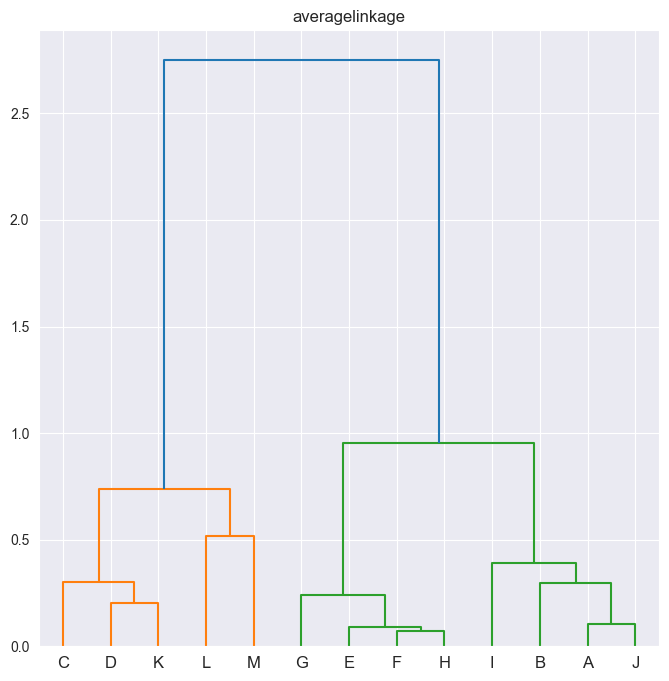

In [40]:
scaler=StandardScaler().set_output(transform='pandas')
df_scaled=scaler.fit_transform(df)
link='average'
mergings=linkage(df_scaled,method=link)
plt.figure(figsize=(8,8))
dendrogram(mergings,labels=list(df_scaled.index))
plt.title(link + 'linkage')
plt.show()

## Using sklearn

In [41]:
clust=AgglomerativeClustering(n_clusters=2)
clust.fit(df_scaled)
clust.labels_

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1])

In [42]:
df_copy=df.copy()
df_copy['label']=clust.labels_
df_copy.sort_values('label')

,X1,X2,label
Name,,,
A,23,150,0
B,24,167,0
F,11,96,0
E,12,102,0
G,15,112,0
H,10,100,0
J,25,145,0
I,34,156,0
C,67,256,1


In [43]:
clusters=[2,3,4,5,6,7]
scores=[]
for c in clusters:
    clust=AgglomerativeClustering(n_clusters=c)
    clust.fit(df_scaled)
    scores.append([c,silhouette_score(df_scaled,clust.labels_)])
df_scores=pd.DataFrame(scores,columns=['cluster','silhouette score'])
df_scores.sort_values('silhouette score',ascending=False)

,cluster,silhouette score
0,2,0.768625
1,3,0.748692
2,4,0.642185
3,5,0.570780
4,6,0.453127
5,7,0.451401


In [44]:
clusters=[2,3,4,5,6,7]
linkages=['ward','single','complete','average']
scores=[]
for c in clusters:
    for l in linkages:
        clust=AgglomerativeClustering(n_clusters=c,linkage=l)
        clust.fit(df_scaled)
        scores.append([c,l,silhouette_score(df_scaled,clust.labels_)])
df_scores=pd.DataFrame(scores,columns=['cluster','linkage','silhouette score'])
df_scores.sort_values('silhouette score',ascending=False)

,cluster,linkage,silhouette score
0,2,ward,0.768625
1,2,single,0.768625
2,2,complete,0.768625
3,2,average,0.768625
4,3,ward,0.748692
5,3,single,0.748692
6,3,complete,0.748692
7,3,average,0.748692
8,4,ward,0.642185
10,4,complete,0.642185


In [45]:
milk=pd.read_csv('milk.csv',index_col=0)
milk_scaled=scaler.fit_transform(milk)

In [46]:
clusters=[2,3,4,5,6,7]
linkages=['ward','single','complete','average']
scores=[]
for c in clusters:
    for l in linkages:
        clust=AgglomerativeClustering(n_clusters=c,linkage=l)
        clust.fit(milk_scaled)
        scores.append([c,l,silhouette_score(milk_scaled,clust.labels_)])
df_scores=pd.DataFrame(scores,columns=['cluster','linkage','silhouette score'])
df_scores.sort_values('silhouette score',ascending=False)

,cluster,linkage,silhouette score
4,3,ward,0.539160
0,2,ward,0.525851
3,2,average,0.518685
1,2,single,0.518685
7,3,average,0.487576
6,3,complete,0.487576
2,2,complete,0.455789
8,4,ward,0.443481
18,6,complete,0.419614
11,4,average,0.416015


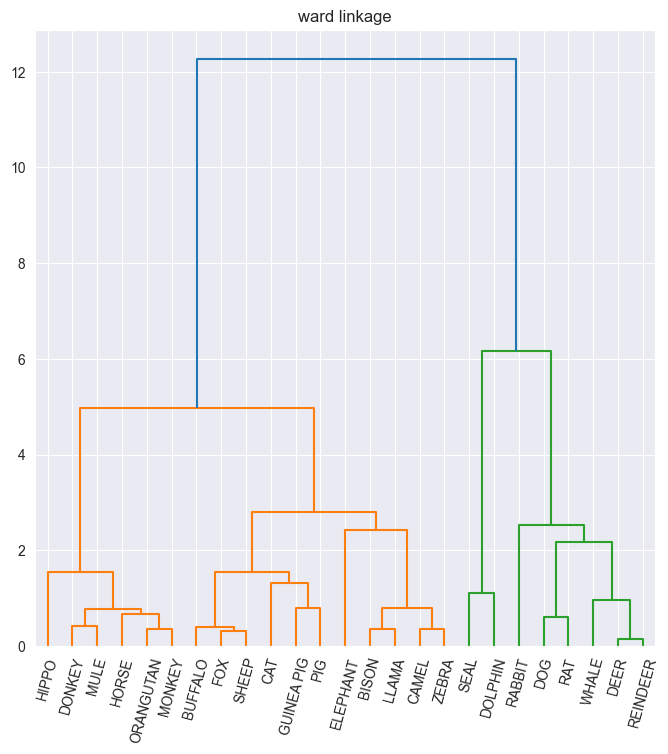

In [47]:
link='ward'
mergings=linkage(milk_scaled,method=link)
plt.figure(figsize=(8,8))
dendrogram(mergings,labels=list(milk_scaled.index))
plt.title(link + ' linkage')
plt.xticks(rotation=75)
plt.show()

In [48]:
nutrient=pd.read_csv('nutrient.csv',index_col=0)
nutrient_scaled = scaler.fit_transform(nutrient)
clusters = [2, 3, 4, 5, 6, 7]
linkages = ['ward', 'single', 'complete', 'average']
scores = []
for c in clusters:
    for l in linkages:
        clust = AgglomerativeClustering(n_clusters=c, linkage=l)
        clust.fit(nutrient_scaled)
        scores.append([c, l, silhouette_score(nutrient_scaled, clust.labels_)])
df_scores = pd.DataFrame(scores, columns=['cluster', 'linkage', 'silhouette score'])
df_scores.sort_values('silhouette score', ascending=False)

,cluster,linkage,silhouette score
1,2,single,0.448342
5,3,single,0.445319
7,3,average,0.445319
8,4,ward,0.415801
10,4,complete,0.415801
3,2,average,0.413451
4,3,ward,0.403730
6,3,complete,0.403730
14,5,complete,0.400003
15,5,average,0.400003


In [49]:
nutrient

,energy,protein,fat,calcium,iron
Food_Item,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7
CHICKEN BROILED,115,20,3,8,1.4
CHICKEN CANNED,170,25,7,12,1.5
BEEF HEART,160,26,5,14,5.9
LAMB LEG ROAST,265,20,20,9,2.6


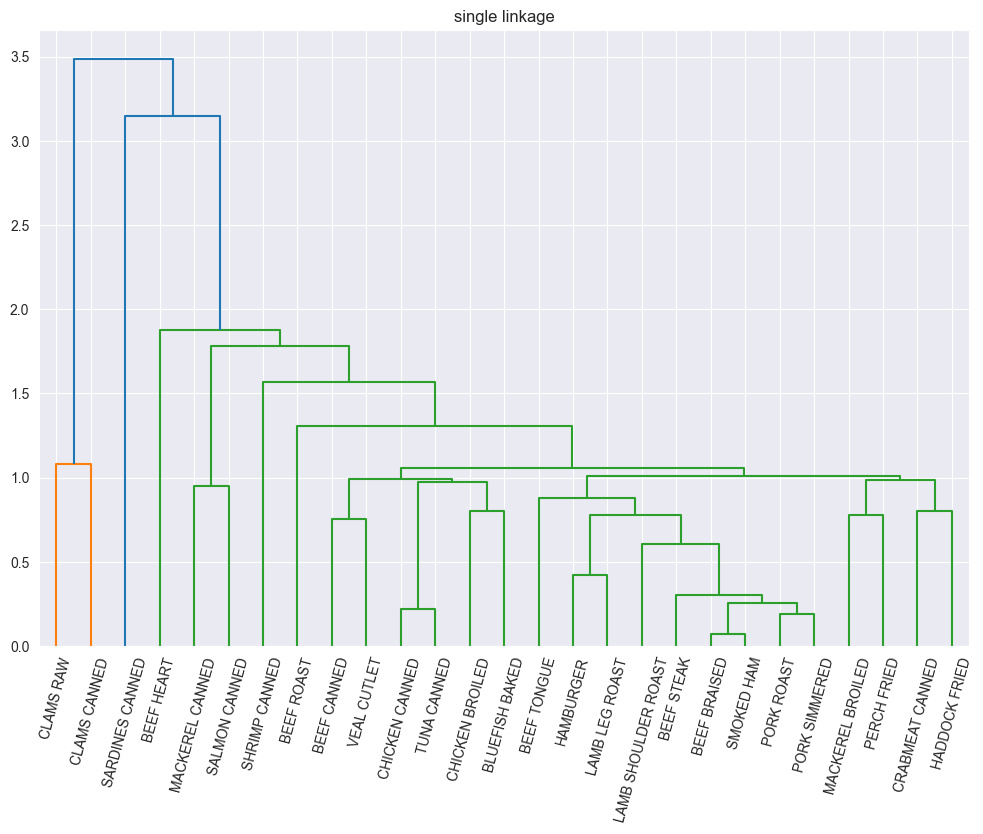

In [50]:
link='single'
mergings=linkage(nutrient_scaled,method=link)
plt.figure(figsize=(12,8))
dendrogram(mergings,labels=list(nutrient_scaled.index))
plt.title(link + ' linkage')
plt.xticks(rotation=75)
plt.show()

In [52]:
milk=pd.read_csv('milk.csv',index_col=0)
scaler=StandardScaler()
milk_scaled=scaler.fit_transform(milk)

In [55]:
clust=KMeans(random_state=25,n_clusters=3)
clust.fit(milk_scaled)
clust.labels_

array([1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 0, 0, 0, 0,
       0, 0, 0], dtype=int32)

In [59]:
clust=KMeans(random_state=25,n_clusters=2)
clust.fit(milk_scaled)
clust.inertia_

49.854659507364545

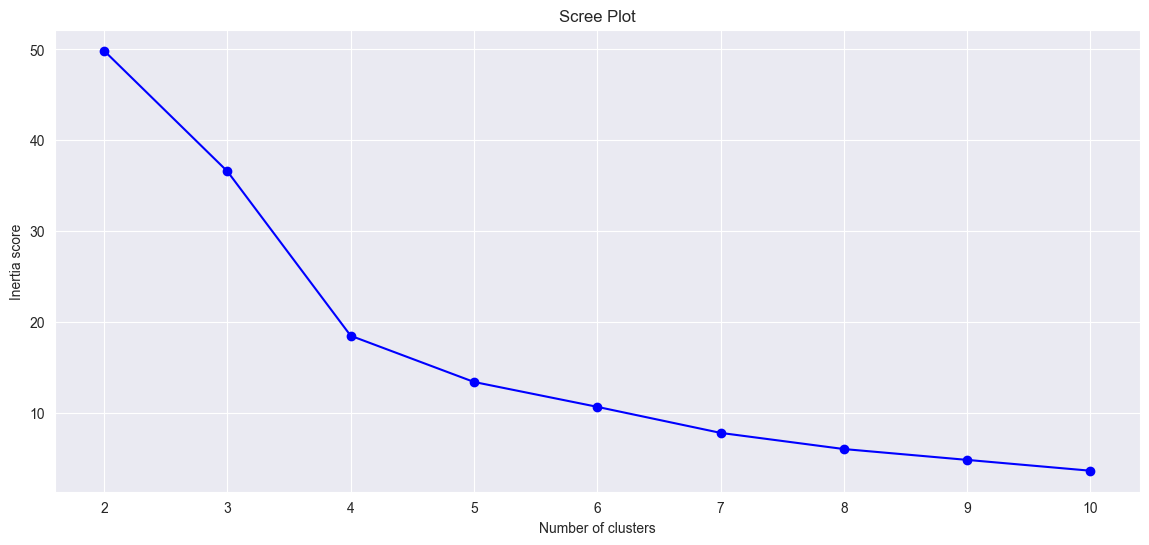

In [71]:
nclust1=[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
nclust=[2,3,4,5,6,7,8,9,10]
wss=[]
for n in nclust:
    clust=KMeans(random_state=25,n_clusters=n)
    clust.fit(milk_scaled)
    wss.append([n, clust.inertia_])
df_scores=pd.DataFrame(scores,columns=['cluster','inertia score'])
plt.figure(figsize=(14,6))
plt.plot(df_scores['cluster'],df_scores['inertia score'],marker='o',color='blue')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia score')
plt.title('Scree Plot')
plt.show()

In [72]:
scores = []
for i in range(2,11):
    clust = KMeans(random_state=25,n_clusters=i)
    clust.fit(milk_scaled)
    scores.append([i, silhouette_score(milk_scaled,clust.labels_)])
df_scores = pd.DataFrame(scores, columns=['cluster','score'])
df_scores.sort_values('score',ascending=False)

,cluster,score
0,2,0.525851
2,4,0.423246
4,6,0.412161
8,10,0.407573
7,9,0.406707
3,5,0.399843
5,7,0.398780
6,8,0.397209
1,3,0.353503


In [73]:
df_copy = milk.copy()
clust = KMeans(random_state=25,n_clusters=2)
clust.fit(milk_scaled)
df_copy['cluster']=clust.labels_
df_copy.groupby('cluster').mean()

,water,protein,fat,lactose,ash
cluster,,,,,
0,63.362500,10.412500,21.662500,1.975000,1.347500
1,85.158824,4.235294,4.964706,5.147059,0.635294


In [74]:
df_copy = milk.copy()
clust = KMeans(random_state=25,n_clusters=4)
clust.fit(milk_scaled)
df_copy['cluster']=clust.labels_
df_copy.groupby('cluster').mean()

,water,protein,fat,lactose,ash
cluster,,,,,
0,69.266667,10.500000,16.066667,2.483333,1.566667
1,89.128571,1.928571,2.814286,5.814286,0.348571
2,82.380000,5.850000,6.470000,4.680000,0.836000
3,45.650000,10.150000,38.450000,0.450000,0.690000


In [75]:
df_copy[df_copy['cluster']==0]

,water,protein,fat,lactose,ash,cluster
Animal,,,,,,
DOG,76.3,9.3,9.5,3.0,1.2,0
RABBIT,71.3,12.3,13.1,1.9,2.3,0
RAT,72.5,9.2,12.6,3.3,1.4,0
DEER,65.9,10.4,19.7,2.6,1.4,0
REINDEER,64.8,10.7,20.3,2.5,1.4,0
WHALE,64.8,11.1,21.2,1.6,1.7,0


In [76]:
df_copy[df_copy['cluster']==1]

,water,protein,fat,lactose,ash,cluster
Animal,,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35,1
ORANGUTAN,88.5,1.4,3.5,6.0,0.24,1
MONKEY,88.4,2.2,2.7,6.4,0.18,1
DONKEY,90.3,1.7,1.4,6.2,0.40,1
HIPPO,90.4,0.6,4.5,4.4,0.10,1
MULE,90.0,2.0,1.8,5.5,0.47,1
ZEBRA,86.2,3.0,4.8,5.3,0.70,1


In [77]:
nut = pd.read_csv('nutrient.csv', index_col=0)
scaler = StandardScaler()
nut_scaled = scaler.fit_transform(nut)
clust = KMeans(random_state=25, n_clusters=3)
clust.fit(nut_scaled)
clust.labels_

array([1, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 2, 2, 0,
       2, 0, 0, 2, 2], dtype=int32)

In [78]:
scores = []
for i in range(2,11):
    clust = KMeans(random_state=25,n_clusters=i)
    clust.fit(nut_scaled)
    scores.append([i, silhouette_score(nut_scaled,clust.labels_)])
df_scores = pd.DataFrame(scores, columns=['cluster','score'])
df_scores.sort_values('score',ascending=False)

,cluster,score
2,4,0.419974
5,7,0.402943
4,6,0.381370
3,5,0.378018
7,9,0.377910
6,8,0.377523
8,10,0.366987
1,3,0.357822
0,2,0.325778


In [86]:
df_copy = nut.copy()
clust = KMeans(random_state=25, n_clusters=4)
clust.fit(nut_scaled)
df_copy['cluster']=clust.labels_
df_copy.groupby('cluster').mean()

,energy,protein,fat,calcium,iron
cluster,,,,,
0,151.666667,18.333333,7.666667,227.666667,1.666667
1,341.875000,18.750000,28.875000,8.750000,2.437500
2,163.928571,20.714286,7.714286,19.857143,2.028571
3,57.500000,9.000000,1.000000,78.000000,5.700000


In [81]:
df_copy = nut.copy()
clust = KMeans(random_state=25, n_clusters=7)
clust.fit(nut_scaled)
df_copy['cluster']=clust.labels_
df_copy.groupby('cluster').mean()

,energy,protein,fat,calcium,iron
cluster,,,,,
0,137.500,16.50,7.000,158.00,1.2500
1,341.875,18.75,28.875,8.75,2.4375
2,140.000,23.00,4.400,30.00,1.4600
3,57.500,9.00,1.000,78.00,5.7000
4,192.500,23.00,10.250,12.25,3.7500
5,165.000,16.60,9.000,15.80,1.2200
6,180.000,22.00,9.000,367.00,2.5000


In [87]:
df_copy[df_copy['cluster']==0]

,energy,protein,fat,calcium,iron,cluster
Food_Item,,,,,,
MACKEREL CANNED,155,16,9,157,1.8,0
SALMON CANNED,120,17,5,159,0.7,0
SARDINES CANNED,180,22,9,367,2.5,0


In [88]:
df_copy[df_copy['cluster']==1]

,energy,protein,fat,calcium,iron,cluster
Food_Item,,,,,,
BEEF BRAISED,340,20,28,9,2.6,1
BEEF ROAST,420,15,39,7,2.0,1
BEEF STEAK,375,19,32,9,2.6,1
LAMB LEG ROAST,265,20,20,9,2.6,1
LAMB SHOULDER ROAST,300,18,25,9,2.3,1
SMOKED HAM,340,20,28,9,2.5,1
PORK ROAST,340,19,29,9,2.5,1
PORK SIMMERED,355,19,30,9,2.4,1


In [89]:
df_copy[df_copy['cluster']==2]

,energy,protein,fat,calcium,iron,cluster
Food_Item,,,,,,
HAMBURGER,245,21,17,9,2.7,2
BEEF CANNED,180,22,10,17,3.7,2
CHICKEN BROILED,115,20,3,8,1.4,2
CHICKEN CANNED,170,25,7,12,1.5,2
BEEF HEART,160,26,5,14,5.9,2
BEEF TONGUE,205,18,14,7,2.5,2
VEAL CUTLET,185,23,9,9,2.7,2
BLUEFISH BAKED,135,22,4,25,0.6,2
CRABMEAT CANNED,90,14,2,38,0.8,2


In [90]:
df_copy[df_copy['cluster']==3]

,energy,protein,fat,calcium,iron,cluster
Food_Item,,,,,,
CLAMS RAW,70,11,1,82,6.0,3
CLAMS CANNED,45,7,1,74,5.4,3


In [107]:
milk = pd.read_csv('milk.csv', index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled = scaler.fit_transform(milk)
clust = DBSCAN(eps = 0.6, min_samples=2)
clust.fit(milk_scaled)
clust.labels_

array([ 0,  0,  0,  0, -1,  1,  1,  2, -1, -1,  2,  1,  0, -1,  1,  2, -1,
       -1, -1, -1,  3,  3, -1, -1, -1])

In [108]:
df_copy = milk.copy()
df_copy['clust'] = clust.labels_
df_copy

,water,protein,fat,lactose,ash,clust
Animal,,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35,0
ORANGUTAN,88.5,1.4,3.5,6.0,0.24,0
MONKEY,88.4,2.2,2.7,6.4,0.18,0
DONKEY,90.3,1.7,1.4,6.2,0.40,0
HIPPO,90.4,0.6,4.5,4.4,0.10,-1
CAMEL,87.7,3.5,3.4,4.8,0.71,1
BISON,86.9,4.8,1.7,5.7,0.90,1
BUFFALO,82.1,5.9,7.9,4.7,0.78,2
GUINEA PIG,81.9,7.4,7.2,2.7,0.85,-1


In [109]:
inliers = milk_scaled.copy()
inliers['label'] = clust.labels_
inliers = inliers[inliers['label']!=-1]
silhouette_score(inliers.iloc[:,:-1], inliers['label'])

0.5934459505692155

In [119]:
eps_lst = [0.2,0.4,0.6,0.8,1,1.2]
sample_lst = [2,3,4,5]
scores = []
for e in eps_lst:
    for s in sample_lst:
        clust = DBSCAN(eps=e, min_samples=s)
        clust.fit(milk_scaled)
        inliers = milk_scaled.copy()
        inliers['label'] = clust.labels_
        inliers = inliers[inliers['label']!=-1]
        if len(np.unique(clust.labels_)) > 2:
            scores.append([e,s,silhouette_score(inliers.iloc[:,:-1], inliers['label'])]) #Becase we need at least 2 clusters for silhouette score.
df_scores = pd.DataFrame(scores, columns=['epsilon','min sample', 'silhouette score'])
df_scores.sort_values('silhouette score',ascending=False)

,epsilon,min sample,silhouette score
0,0.4,2,0.651894
9,1.0,3,0.647387
2,0.6,2,0.593446
10,1.2,2,0.552889
4,0.6,4,0.551975
1,0.4,3,0.538518
3,0.6,3,0.534443
6,0.8,3,0.533038
5,0.8,2,0.464674
7,0.8,4,0.457151


In [116]:
clust = DBSCAN(eps = 0.4, min_samples=4)
clust.fit(milk_scaled)
print(clust.labels_)
print(np.unique(clust.labels_))
print(len(np.unique(clust.labels_)))

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1]
[-1]
1


In [117]:
clust = DBSCAN(eps = 0.7, min_sampes=2)
clust.fit(milk_scaled)
print(clust.labels_)
print(np.unique(clust.labels_))
print(len(np.unique(clust.labels_)))

[ 0  0  0  0 -1  0  0  1 -1 -1  1  0  0 -1  0  1  2 -1 -1  2  3  3 -1 -1
 -1]
[-1  0  1  2  3]
5


## Usage with Supervised learning

In [145]:
kyph = pd.read_csv('Kyphosis.csv')
y = kyph['Kyphosis']
X = kyph.drop(['Kyphosis'],axis=1)
train, test = train_test_split(kyph, test_size=0.3, random_state=25, stratify=y)

In [146]:
y_train = train['Kyphosis']
X_train = train.drop('Kyphosis',axis=1)
y_test = test['Kyphosis']
X_test = test.drop('Kyphosis', axis=1)

In [147]:
X.shape

(81, 3)

In [148]:
X_train.shape

(56, 3)

In [149]:
scaler = StandardScaler().set_output(transform='pandas')
X_trn_scaled = scaler.fit_transform(X_train)
X_tst_scaled = scaler.transform(X_test)
scores = []
for i in range(2,11):
    clust = KMeans(random_state=25,n_clusters=i)
    clust.fit(X_trn_scaled)
    scores.append([i, silhouette_score(X_trn_scaled,clust.labels_)])
df_scores = pd.DataFrame(scores, columns=['cluster','score'])
df_scores.sort_values('score',ascending=False)

,cluster,score
2,4,0.396206
8,10,0.393340
7,9,0.366559
3,5,0.351667
0,2,0.348402
1,3,0.330521
6,8,0.323228
5,7,0.287655
4,6,0.285068


In [150]:
clust = KMeans(random_state=25,n_clusters=4)
clust.fit(X_trn_scaled)
train['cluster'] = clust.labels_
train

,Kyphosis,Age,Number,Start,cluster
63,absent,118,3,16,3
45,present,139,3,10,3
66,absent,195,2,17,3
75,absent,178,4,15,3
60,present,130,4,1,1
25,absent,9,5,13,2
21,present,105,6,5,0
17,absent,175,5,13,3
58,absent,51,7,9,0
0,absent,71,3,5,1


In [151]:
clust.predict(X_tst_scaled)

array([0, 2, 2, 3, 3, 1, 1, 3, 3, 3, 2, 2, 2, 2, 1, 0, 3, 0, 2, 3, 3, 3,
       2, 1, 3], dtype=int32)

In [152]:
clust = KMeans(random_state=25,n_clusters=4)
clust.fit(X_trn_scaled)
X_trn_scaled['cluster'] = clust.labels_
X_trn_scaled.groupby('cluster').mean()

,Age,Number,Start
cluster,,,
0,-0.232831,1.910084,-0.863024
1,-0.116820,-0.138767,-1.652074
2,-1.232529,-0.570765,0.487466
3,0.728342,-0.254301,0.593685
